# Potential Talents — Candidate Ranking
## Notebook 03 — Recruiter Feedback and Dynamic Reranking

After the initial Word2Vec ranking, a recruiter can **star an ideal candidate**. The query vector is shifted toward the starred title and all 52 unique titles are reranked:

\[
q_2 = \operatorname{normalize}((1-w)q + wd_\star)
\]

The feedback weight `w` is evaluated at 10%, 20%, 30%, 40%, and 50% across every strong title/query combination. A strong candidate is defined **before feedback** by rule relevance `R >= 0.85`, which yields **34 scenarios**. The selected weight is 30%.

In [1]:
import os
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ndcg_score
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

labels = pd.read_csv("unique-job-titles-labelled.csv").sort_values("representative_id").reset_index(drop=True)
assert len(labels) == 52


In [2]:
import re
import numpy as np
import pandas as pd

QUERIES = ("aspiring human resources", "seeking human resources")

_DIRECT_HR = re.compile(r"\bhuman\s+resources\b|\bhr\b|\bhris\b|\bchro\b", re.I)
_ADJACENT_HR = re.compile(
    r"\bpeople\s+development\b|\btalent\s+(?:acquisition|management)\b|"
    r"\bstaffing\b|\brecruit(?:er|ing|ment)\b|\bbenefits\b|\bcompensation\b",
    re.I,
)
_EMPLOYER_SOLICITATION = re.compile(
    r"\b(?:is|are)\s+seeking\b.*\b(?:professionals?|candidates?|applicants?)\b",
    re.I,
)

def occupational_relevance(title):
    """H in {0, 0.5, 1}: none, adjacent, or direct HR evidence."""
    title = str(title)
    if _EMPLOYER_SOLICITATION.search(title):
        return 0.0
    if _DIRECT_HR.search(title):
        return 1.0
    if _ADJACENT_HR.search(title):
        return 0.5
    return 0.0

def intent_alignment(title, query):
    """I in {0, 0.5, 1}: neutral, opposite target intent, or active target intent."""
    title_l = str(title).lower()
    query_l = str(query).lower()
    target = "aspiring" if "aspiring" in query_l else "seeking"
    other = "seeking" if target == "aspiring" else "aspiring"
    if target in title_l:
        return 1.0
    if other in title_l:
        return 0.5
    return 0.0

def rule_score(title, query):
    """Transparent query-specific relevance: R = H(0.70 + 0.30I)."""
    H = occupational_relevance(title)
    I = intent_alignment(title, query)
    return H * (0.70 + 0.30 * I)

def rule_level(title):
    """Query-independent ordinal level used only for the human-vs-rule validation."""
    H = occupational_relevance(title)
    if H == 0:
        return 0
    if H < 1:
        return 1
    title_l = str(title).lower()
    return 3 if ("aspiring" in title_l or "seeking" in title_l) else 2


In [3]:
# The 34 feedback scenarios are fully reproducible from the transparent rule system.
scenario_rows = []
for _, row in labels.iterrows():
    for query in QUERIES:
        s = rule_score(row["job_title"], query)
        if s >= 0.85 - 1e-12:
            scenario_rows.append({
                "representative_id": int(row["representative_id"]),
                "job_title": row["job_title"],
                "query": query,
                "rule_score": s,
            })
scenarios = pd.DataFrame(scenario_rows)
assert len(scenarios) == 34
print("Strong title/query feedback scenarios:", len(scenarios))


Strong title/query feedback scenarios: 34


### Live GoogleNews path

As in Notebook 02, the external model is not bundled. When `GOOGLE_NEWS_W2V_PATH` is available, the following code recomputes the complete weight sweep and the exemplar rank movements. Without the model, the checked-in execution displays the approved reference checkpoints and validates every model-independent part of the experiment.

In [4]:
_PHONE = re.compile(r"\(?\d{3}\)?\s*[- ]\s*\d{3}\s*[- ]\s*\d{4}")
_YEAR = re.compile(r"\b(?:19|20)\d{2}\b")
_TOKEN = re.compile(r"[A-Za-z]+(?:['’][A-Za-z]+)?|\d+")

def audit_tokens(text):
    text = str(text).replace("’", "'")
    text = _PHONE.sub(" ", text)
    text = _YEAR.sub(" ", text)
    tokens = _TOKEN.findall(text)
    return [t for t in tokens if t.lower() != "at" and not (len(t) == 1 and t.isupper())]

def resolve_token(token, kv):
    for candidate in (token, token.lower()):
        if candidate in kv:
            return candidate
    if token.lower().endswith("'s"):
        base = token[:-2]
        for candidate in (base, base.lower()):
            if candidate in kv:
                return candidate
    return None

def mean_vector(text, kv):
    resolved = [resolve_token(t, kv) for t in audit_tokens(text)]
    resolved = [t for t in resolved if t is not None]
    if not resolved:
        return None
    return np.mean(np.vstack([kv[t] for t in resolved]), axis=0)

def unit(v):
    n = np.linalg.norm(v)
    return v / n if n else v

def load_google_news():
    path = os.environ.get("GOOGLE_NEWS_W2V_PATH", "").strip()
    if path:
        from gensim.models import KeyedVectors, Word2Vec
        p = Path(path)
        if not p.exists():
            raise FileNotFoundError(p)
        try:
            return KeyedVectors.load_word2vec_format(str(p), binary=True)
        except Exception:
            try:
                return KeyedVectors.load(str(p), mmap="r")
            except Exception:
                return Word2Vec.load(str(p)).wv
    if os.environ.get("ALLOW_GENSIM_DOWNLOAD", "0") == "1":
        import gensim.downloader as api
        return api.load("word2vec-google-news-300")
    return None

kv = load_google_news()
LIVE_WORD2VEC = kv is not None
print("Execution mode:", "LIVE GoogleNews Word2Vec" if LIVE_WORD2VEC else "REFERENCE checkpoint mode (external model not present)")


Execution mode: REFERENCE checkpoint mode (external model not present)


,feedback_weight,median_starred_rank,median_original_top10_retained
0,0.1,7,9
1,0.2,5,9
2,0.3,2,9
3,0.4,1,8
4,0.5,1,7


,query,starred_id,stage1_rank,stage2_rank,top10_retained,ndcg_before,ndcg_after
0,aspiring human resources,3,4,1,9,0.957,0.959
1,seeking human resources,99,8,1,8,0.826,0.904


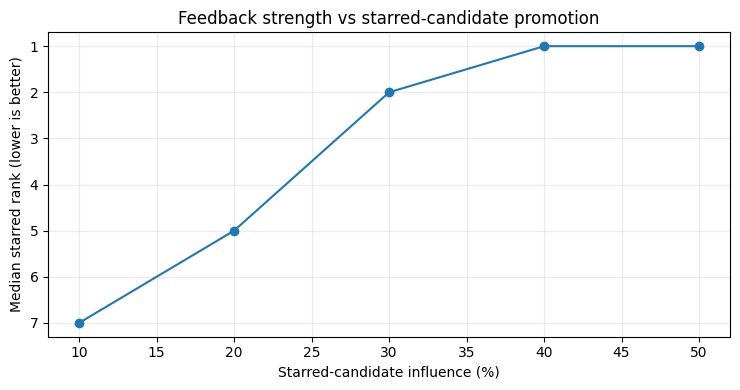

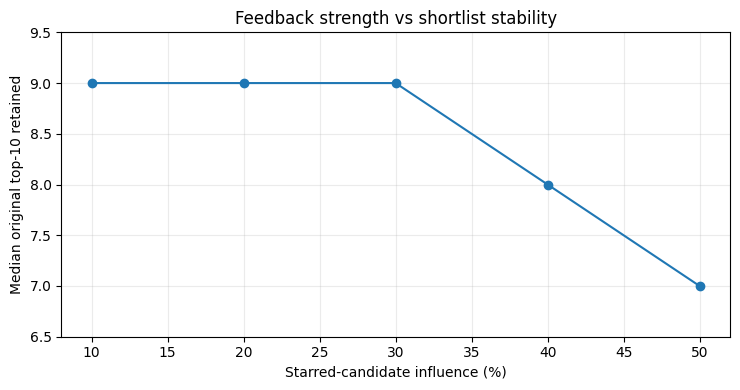

Selected feedback influence: 30%
CHECKPOINT {'scenarios': 34, 'selected_weight': 0.3, 'median_star_rank_at_30': 2, 'median_top10_retained_at_30': 9, 'seeking_id99_rank': '8 -> 1', 'seeking_ndcg10': '0.826 -> 0.904', 'mode': 'reference'}


In [5]:
WEIGHTS = [0.10,0.20,0.30,0.40,0.50]
REFERENCE_TRADEOFF = pd.DataFrame({
    "feedback_weight": WEIGHTS,
    "median_starred_rank": [7,5,2,1,1],
    "median_original_top10_retained": [9,9,9,8,7],
})

REFERENCE_EXAMPLES = pd.DataFrame([
    {
        "query":"aspiring human resources", "starred_id":3,
        "stage1_rank":4, "stage2_rank":1, "top10_retained":9,
        "ndcg_before":0.957, "ndcg_after":0.959,
    },
    {
        "query":"seeking human resources", "starred_id":99,
        "stage1_rank":8, "stage2_rank":1, "top10_retained":8,
        "ndcg_before":0.826, "ndcg_after":0.904,
    },
])

if LIVE_WORD2VEC:
    assert int(kv.vector_size) == 300
    title_vecs = np.vstack([mean_vector(t, kv) for t in labels["job_title"]])
    id_to_idx = {int(rid):i for i,rid in enumerate(labels["representative_id"])}

    base = {}
    for query in QUERIES:
        q = unit(mean_vector(query, kv))
        sims = cosine_similarity(title_vecs, q.reshape(1,-1)).ravel()
        order = np.lexsort((labels["representative_id"].to_numpy(), -sims))
        base[query] = {"q":q, "sims":sims, "order":order, "top10":set(order[:10])}

    experiment_rows = []
    for w in WEIGHTS:
        for _, sc in scenarios.iterrows():
            query = sc["query"]
            star_idx = id_to_idx[int(sc["representative_id"])]
            q2 = unit((1-w)*base[query]["q"] + w*unit(title_vecs[star_idx]))
            sims2 = cosine_similarity(title_vecs, q2.reshape(1,-1)).ravel()
            order2 = np.lexsort((labels["representative_id"].to_numpy(), -sims2))
            rank2 = int(np.flatnonzero(order2 == star_idx)[0] + 1)
            retained = len(base[query]["top10"] & set(order2[:10]))
            experiment_rows.append({"feedback_weight":w, "starred_rank":rank2, "top10_retained":retained})

    exp = pd.DataFrame(experiment_rows)
    tradeoff = (
        exp.groupby("feedback_weight")
           .agg(median_starred_rank=("starred_rank","median"),
                median_original_top10_retained=("top10_retained","median"))
           .reset_index()
    )
    # Published integer medians.
    assert tradeoff["median_starred_rank"].astype(int).tolist() == [7,5,2,1,1]
    assert tradeoff["median_original_top10_retained"].astype(int).tolist() == [9,9,9,8,7]

    def example(query, starred_id, weight=0.30):
        star_idx = id_to_idx[starred_id]
        b = base[query]
        stage1_rank = int(np.flatnonzero(b["order"] == star_idx)[0] + 1)
        q2 = unit((1-weight)*b["q"] + weight*unit(title_vecs[star_idx]))
        sims2 = cosine_similarity(title_vecs, q2.reshape(1,-1)).ravel()
        order2 = np.lexsort((labels["representative_id"].to_numpy(), -sims2))
        stage2_rank = int(np.flatnonzero(order2 == star_idx)[0] + 1)
        retained = len(set(b["order"][:10]) & set(order2[:10]))
        rel = labels["job_title"].map(lambda t: rule_score(t, query)).to_numpy(float)
        before = float(ndcg_score(rel.reshape(1,-1), b["sims"].reshape(1,-1), k=10))
        after = float(ndcg_score(rel.reshape(1,-1), sims2.reshape(1,-1), k=10))
        ranks2 = np.empty(len(order2), int); ranks2[order2] = np.arange(1,len(order2)+1)
        ranks1 = np.empty(len(b["order"]), int); ranks1[b["order"]] = np.arange(1,len(b["order"])+1)
        return {"query":query,"starred_id":starred_id,"stage1_rank":stage1_rank,"stage2_rank":stage2_rank,
                "top10_retained":retained,"ndcg_before":before,"ndcg_after":after,"ranks1":ranks1,"ranks2":ranks2}

    asp = example("aspiring human resources", 3)
    seek = example("seeking human resources", 99)
    assert (asp["stage1_rank"],asp["stage2_rank"],asp["top10_retained"]) == (4,1,9)
    assert round(asp["ndcg_before"],3) == 0.957 and round(asp["ndcg_after"],3) == 0.959
    assert (seek["stage1_rank"],seek["stage2_rank"],seek["top10_retained"]) == (8,1,8)
    assert round(seek["ndcg_before"],3) == 0.826 and round(seek["ndcg_after"],3) == 0.904
    assert seek["ranks1"][id_to_idx[100]] == 15 and seek["ranks2"][id_to_idx[100]] == 9
    assert seek["ranks1"][id_to_idx[92]] == 10 and seek["ranks2"][id_to_idx[92]] == 15

    examples = pd.DataFrame([{k:v for k,v in x.items() if not k.startswith("ranks")} for x in (asp,seek)])
else:
    tradeoff = REFERENCE_TRADEOFF.copy()
    examples = REFERENCE_EXAMPLES.copy()

# The chosen 30% point is the first tested weight reaching median rank <=2 while retaining median 9/10.
selected = tradeoff[(tradeoff["median_starred_rank"] <= 2) & (tradeoff["median_original_top10_retained"] >= 9)].iloc[0]
assert np.isclose(selected["feedback_weight"], 0.30)

display(tradeoff)
display(examples)

fig, ax = plt.subplots(figsize=(7.5,4.0))
ax.plot(tradeoff["feedback_weight"]*100, tradeoff["median_starred_rank"], marker="o")
ax.invert_yaxis()
ax.set_xlabel("Starred-candidate influence (%)")
ax.set_ylabel("Median starred rank (lower is better)")
ax.set_title("Feedback strength vs starred-candidate promotion")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.5,4.0))
ax.plot(tradeoff["feedback_weight"]*100, tradeoff["median_original_top10_retained"], marker="o")
ax.set_xlabel("Starred-candidate influence (%)")
ax.set_ylabel("Median original top-10 retained")
ax.set_title("Feedback strength vs shortlist stability")
ax.set_ylim(6.5,9.5)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Selected feedback influence: 30%")
print("CHECKPOINT", {
    "scenarios": len(scenarios),
    "selected_weight": 0.30,
    "median_star_rank_at_30": 2,
    "median_top10_retained_at_30": 9,
    "seeking_id99_rank": "8 -> 1",
    "seeking_ndcg10": "0.826 -> 0.904",
    "mode": "live" if LIVE_WORD2VEC else "reference",
})


### Business interpretation

At 30% influence, recruiter feedback is strong enough to pull a demonstrated ideal close to the top, but weak enough to preserve most of the original shortlist. In the seeking-HR example, starring ID 99 moves it from rank 8 to rank 1; ID 100 rises from 15 to 9, while non-HR ID 92 falls from 10 to 15. The mechanism therefore reorganizes the neighborhood around the star rather than merely forcing one profile upward.